In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, run_xso_stabilityscan, avg_tail

import cariaco_obs as co
import cariaco_baseline_setups as cbs
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cbs, pu, pp):            # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)


In [2]:
# === Cell 1: setup — forcing, scan axes, binning machinery, obs target ===
import numpy as np, importlib
import cariaco_baseline_setups as cbs
import cariaco_obs as co
import parscan_utils as pu
import matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan
for m in (cbs, co, pu): importlib.reload(m)

# Upwelling forcing (Inflow__FN, Inflow__de, Temperature__value) + R0-tuned overrides
_, _, bin_defs, monthly_up, forcing_up = co.load_cariaco_targets(
    'upwelling', months='hplc', agg='median', include_temperature=True)
N = cbs.N_CLASSES
fixed = {**forcing_up, 'Grazing__KsZ': np.full(N, 0.30), 'ZooLoss__rate': 0.3}

# Scan axes  (diatom_exp = -0.45 reproduces R0; > 0 = large cells grow faster)
EXP_VALS    = np.round(np.linspace(-0.45, 0.20, 14), 4)
THRESH_VALS = [5.0, 10.0, 20.0, 40.0]    # crossover ESD [µm], straddling Nano/Micro

# Binning (identical operator to the obs side)
phyto_esd = cbs.phyto_esd
W         = pu.phyto_bin_matrix(phyto_esd, bin_defs)        # (3, N): Pico/Nano/Micro
geomeans  = pu.CARIACO_PHYTO_BIN_GEOMEANS                   # [0.63, 6.3, 63.0]
TAIL      = 1000

# Obs upwelling target: per-month fractions -> median
pcols    = [b['column'] for b in bin_defs if b['type'] == 'phyto']
Pobs     = monthly_up[pcols].dropna().values
obs_frac = np.nanmedian(Pobs / Pobs.sum(axis=1, keepdims=True), axis=0)
obs_mcs  = np.nanmedian(10.0 ** ((Pobs / Pobs.sum(axis=1, keepdims=True)) @ np.log10(geomeans)))
print('obs upwelling  Pico/Nano/Micro =', np.round(obs_frac, 3), ' mcs =', round(obs_mcs, 2), 'µm')

obs upwelling  Pico/Nano/Micro = [0.448 0.224 0.313]  mcs = 4.84 µm


In [4]:
# === omni stabilization: sigma (kernel width) x m_Z at bloom F_N=8 ===
SIGMA_VALS = [0.10, 0.15, 0.20, 0.25]          # toward Mattern (~0.106 std equiv); 0.25 = current
MZ_VALS    = np.round(np.linspace(0.3, 1.2, 10), 3)
FN_TGT     = 8.0
fixed_sweep = {k: v for k, v in fixed.items() if k not in ('Inflow__FN', 'ZooLoss__rate')}  # de+temp+KsZ
fixed_sweep['Inflow__FN'] = FN_TGT

res_by_sigma = {}
for sg in SIGMA_VALS:
    phiPZ_sg = cbs.compute_grazing_kernel(cbs.phyto_esd, cbs.zoo_esd, 'omni',
                                          theta_opt=10.0, sigma_log=sg)
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups',
                          model_name='model_dist_t3_T',
                          model_setup_name='model_setup_dist_omni_t3_T_slim',
                          param_name='ZooLoss__rate', param_values=MZ_VALS, processes=8,
                          fixed_overrides={**fixed_sweep, 'Grazing__phiPZ': phiPZ_sg})
    res_by_sigma[sg] = res

print(f"{'sigma':>6}{'m_Z':>6}{'Micro':>7}{'mcsP':>7}{'meanZ':>7}{'z95':>7}{'fZ>200':>8}{'ZoP':>7}{'CV':>8}")
for sg in SIGMA_VALS:
    res = res_by_sigma[sg]
    for k, mz in enumerate(MZ_VALS):
        P = res['Phytoplankton__biomass'].isel({'ZooLoss__rate': k}).values[:, -TAIL:]
        Z = res['Zooplankton__biomass'].isel({'ZooLoss__rate': k}).values[:, -TAIL:]
        if np.isnan(P).any() or np.isnan(Z).any():
            print(f"{sg:6.2f}{mz:6.2f}{'  nan (crash)':>40}"); continue
        Pspec=P.mean(axis=1); sumP=Pspec.sum(); b=W@Pspec; f=b/b.sum()
        sP=P.sum(axis=0); cv=sP.std()/abs(sP.mean())
        Zs=Z.mean(axis=1); sumZ=Zs.sum(); zf=Zs/sumZ
        meanZ=10.0**(np.log10(zoo_esd)@zf); z95=zoo_esd[min(np.searchsorted(np.cumsum(zf),0.95),len(zoo_esd)-1)]
        print(f"{sg:6.2f}{mz:6.2f}{f[2]:7.3f}{10.0**(np.log10(geomeans)@f):7.2f}"
              f"{meanZ:7.1f}{z95:7.0f}{Zs[zoo_esd>200].sum()/sumZ:8.3f}{sumZ/sumP:7.3f}{cv:8.4f}")
    print('-'*65)

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1324 on N = -2.65. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 32.4082 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=184.5 on P[8] = -0.00131. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 21656 RHS evaluations for 207 output points (105/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may not for oscillatory predator-prey models), or loosening tolerances via solver_kwargs={'atol': 1e-6, 'rtol': 1e-4}. (This warning fires once per process.)
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub

1D Scan complete. Time taken: 123.412 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=36.31 on N = -4.4. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=54.62 on P[6] = -0.00103. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=85.21 on P[0] = -4.17. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instabili

1D Scan complete. Time taken: 153.7482 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=31.6 on P[0] = -0.0014. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=29.51 on P[6] = -0.00256. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=59.68 on P[0] = -0.0125. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'in

1D Scan complete. Time taken: 141.23236 seconds.
 sigma   m_Z  Micro   mcsP  meanZ    z95  fZ>200    ZoP      CV
  0.10  0.30                             nan (crash)
  0.10  0.40  0.237   3.23   13.1    118   0.025  0.621  0.0015
  0.10  0.50  0.222   3.22   11.3    118   0.016  0.566  0.0026
  0.10  0.60  0.106   2.48   10.4     98   0.000  0.530  0.0015
  0.10  0.70  0.023   2.10    9.4     82   0.000  0.493  0.0011
  0.10  0.80  0.000   2.12    8.4     69   0.000  0.454  0.0007
  0.10  0.90  0.000   2.09    8.1     69   0.000  0.439  0.0023
  0.10  1.00  0.000   2.09    7.6     48   0.000  0.415  0.0005
  0.10  1.10  0.000   2.11    7.1     48   0.000  0.392  0.0004
  0.10  1.20  0.000   2.05    7.0     48   0.000  0.382  0.0004
-----------------------------------------------------------------
  0.15  0.30                             nan (crash)
  0.15  0.40                             nan (crash)
  0.15  0.50  0.000   0.63   11.6    200   0.074  0.570  0.0004
  0.15  0.60  0.000   

In [5]:
# === omni at Mattern sigma: K_sZ x F_N, regime -> bloom (m_Z=0.3) ===
SIGMA_M   = 0.106                                   # = Mattern's 0.15 in the 2sigma^2 convention
KSZ_VALS  = [0.15, 0.20, 0.30, 0.45, 0.60, 0.80]    # Ward 0.15 / Dutkiewicz 0.23 ... up the stable side
FN_SET    = [round(forcing_up['Inflow__FN'], 2), 4.0, 6.0, 8.0]   # regime first
N         = cbs.N_CLASSES
phiPZ_M   = cbs.compute_grazing_kernel(cbs.phyto_esd, cbs.zoo_esd, 'omni', theta_opt=10.0, sigma_log=SIGMA_M)
fixed_kz  = {k: v for k, v in fixed.items() if k not in ('Inflow__FN', 'Grazing__KsZ')}  # de+temp+ZooLoss(0.3)

print(f"obs upwelling: Pico/Nano/Micro={np.round(obs_frac,3)}  mcs={obs_mcs:.2f} µm\n")
for fn in FN_SET:
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups',
                          model_name='model_dist_t3_T', model_setup_name='model_setup_dist_omni_t3_T_slim',
                          param_name='Grazing__KsZ', param_values=[np.full(N, v) for v in KSZ_VALS],
                          processes=8,
                          fixed_overrides={**fixed_kz, 'Inflow__FN': fn, 'Grazing__phiPZ': phiPZ_M})
    print(f"=== F_N = {fn} ===")
    print(f"{'KsZ':>6}{'Micro':>7}{'mcsP':>7}{'meanZ':>7}{'z95':>7}{'fZ>200':>8}{'ZoP':>7}{'CV':>8}")
    for k, kz in enumerate(KSZ_VALS):
        P = res['Phytoplankton__biomass'].isel({'Grazing__KsZ': k}).values[:, -TAIL:]
        Z = res['Zooplankton__biomass'].isel({'Grazing__KsZ': k}).values[:, -TAIL:]
        if np.isnan(P).any() or np.isnan(Z).any():
            print(f"{kz:6.2f}{'   nan (crash)':>40}"); continue
        Pspec=P.mean(axis=1); sumP=Pspec.sum(); b=W@Pspec; f=b/b.sum()
        sP=P.sum(axis=0); cv=sP.std()/abs(sP.mean())
        Zs=Z.mean(axis=1); sumZ=Zs.sum(); zf=Zs/sumZ
        meanZ=10.0**(np.log10(zoo_esd)@zf); z95=zoo_esd[min(np.searchsorted(np.cumsum(zf),0.95),len(zoo_esd)-1)]
        print(f"{kz:6.2f}{f[2]:7.3f}{10.0**(np.log10(geomeans)@f):7.2f}{meanZ:7.1f}"
              f"{z95:7.0f}{Zs[zoo_esd>200].sum()/sumZ:8.3f}{sumZ/sumP:7.3f}{cv:8.4f}")
    print('-'*55)

obs upwelling: Pico/Nano/Micro=[0.448 0.224 0.313]  mcs=4.84 µm

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 6 points using 8 workers...
1D Scan complete. Time taken: 70.75734 seconds.
=== F_N = 2.58 ===
   KsZ  Micro   mcsP  meanZ    z95  fZ>200    ZoP      CV
  0.15  0.184   1.66   20.5    285   0.114  1.185  0.0043
  0.20  0.000   0.70   14.4     98   0.039  1.393  0.0026
  0.30  0.000   0.63    9.2     34   0.022  1.437  0.0008
  0.45  0.000   0.63    6.4     20   0.000  1.259  0.0003
  0.60  0.000   0.63    5.0     20   0.000  0.975  0.0002
  0.80  0.000   0.63    3.8     20   0.000  0.879  0.0003
-------------------------------------------------------
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and se

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=159 on P[0] = -3.63. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=416.9 on P[6] = -0.0465. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 65.91995 seconds.
=== F_N = 4.0 ===
   KsZ  Micro   mcsP  meanZ    z95  fZ>200    ZoP      CV
  0.15                             nan (crash)
  0.20                             nan (crash)
  0.30  0.000   0.83   11.5     98   0.008  1.184  0.0025
  0.45  0.000   0.71    7.4     20   0.000  1.236  0.0005
  0.60  0.000   0.63    5.7     20   0.000  1.142  0.0003
  0.80  0.000   0.63    4.3     20   0.000  0.929  0.0001
-------------------------------------------------------
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 6 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=71.13 on P[0] = -0.0107. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=164.5 on P[5] = -0.00101. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=153.7 on P[9] = -0.00197. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'

1D Scan complete. Time taken: 41.85588 seconds.
=== F_N = 6.0 ===
   KsZ  Micro   mcsP  meanZ    z95  fZ>200    ZoP      CV
  0.15                             nan (crash)
  0.20                             nan (crash)
  0.30                             nan (crash)
  0.45  0.000   1.04    8.8     41   0.000  0.976  0.0010
  0.60  0.000   0.89    6.7     20   0.000  1.003  0.0004
  0.80  0.000   0.76    4.9     20   0.000  0.960  0.0002
-------------------------------------------------------
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 6 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=77.13 on P[0] = -0.00134. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=137.3 on P[4] = -0.00117. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=172 on N = -2.97. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instabi

1D Scan complete. Time taken: 35.50922 seconds.
=== F_N = 8.0 ===
   KsZ  Micro   mcsP  meanZ    z95  fZ>200    ZoP      CV
  0.15                             nan (crash)
  0.20                             nan (crash)
  0.30                             nan (crash)
  0.45  0.038   1.46   10.5     98   0.000  0.802  0.0015
  0.60  0.000   1.18    7.6     41   0.000  0.840  0.0005
  0.80  0.000   0.92    5.7     20   0.000  0.860  0.0003
-------------------------------------------------------


phyto Pico/Nano/Micro = [0.752 0.057 0.192]  mcs=1.73µm  (obs [0.448 0.224 0.313], mcs 4.84)
zoo  meanZ=16.6µm  z95=200µm  fZ>200=0.068  Z:P=1.082


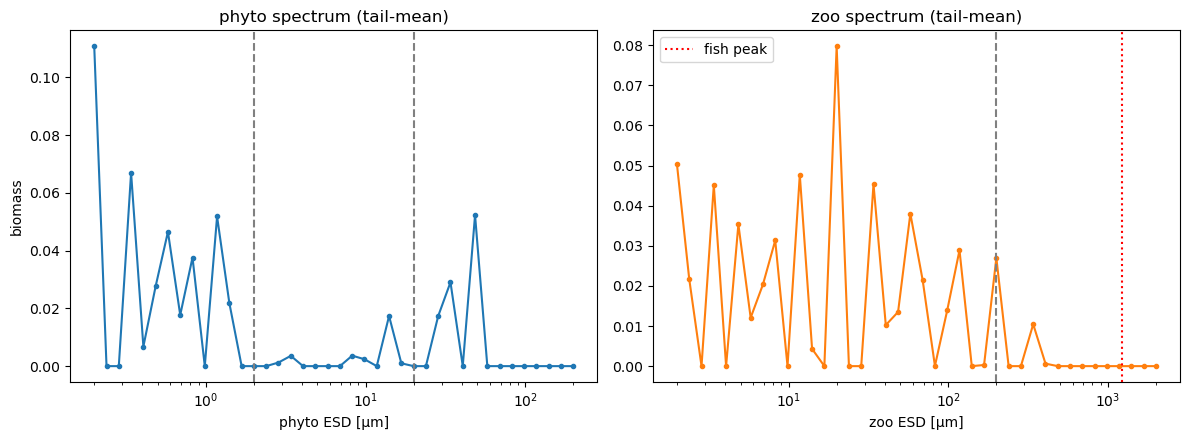

In [6]:
# === omni regime point: full spectra at K_sZ=0.15, F_N=regime, Mattern sigma=0.15 ===
import matplotlib.pyplot as plt
N = cbs.N_CLASSES
out = pu.run_single_point(cbs.model_dist_t3_T, cbs.model_setup_dist_omni_t3_T_mattern_slim,
                          scan_params={'Grazing__KsZ': np.full(N, 0.15)},
                          fixed_overrides={**forcing_up, 'ZooLoss__rate': 0.4})
P = out['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1)
Z = out['Zooplankton__biomass'].values[:, -TAIL:].mean(axis=1)
phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd

b = W @ P; f = b/b.sum(); mcs = 10**(np.log10(geomeans)@f)
zf = Z/Z.sum(); meanZ = 10**(np.log10(zoo_esd)@zf)
z95 = zoo_esd[min(np.searchsorted(np.cumsum(zf),0.95), len(zoo_esd)-1)]
print(f"phyto Pico/Nano/Micro = {np.round(f,3)}  mcs={mcs:.2f}µm  (obs {np.round(obs_frac,3)}, mcs {obs_mcs:.2f})")
print(f"zoo  meanZ={meanZ:.1f}µm  z95={z95:.0f}µm  fZ>200={Z[zoo_esd>200].sum()/Z.sum():.3f}  Z:P={Z.sum()/P.sum():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(phyto_esd, P, marker='o', ms=3)
ax[0].axvline(2, ls='--', c='grey'); ax[0].axvline(20, ls='--', c='grey')
ax[0].set_xscale('log')   # 3-decade size axis; log conventional for spectra — say if you'd prefer linear
ax[0].set_title('phyto spectrum (tail-mean)'); ax[0].set_xlabel('phyto ESD [µm]'); ax[0].set_ylabel('biomass')
ax[1].plot(zoo_esd, Z, marker='o', ms=3, color='C1')
ax[1].axvline(200, ls='--', c='grey'); ax[1].axvline(1230, ls=':', c='red', label='fish peak')
ax[1].set_xscale('log')
ax[1].set_title('zoo spectrum (tail-mean)'); ax[1].set_xlabel('zoo ESD [µm]'); ax[1].legend()
plt.tight_layout(); plt.show()

In [4]:
# ── Cell 7b (omni-Mattern) — LONG IVP runs; IC robustness via IVP, not fsolve ──
import xso
from xso.parscans import StabilityAnalysisHook
N = cbs.N_CLASSES
TAIL = 1000
bin_defs = co.TARGET_BIN_DEFINITIONS
W = pu.phyto_bin_matrix(cbs.phyto_esd, bin_defs); geomeans = pu.CARIACO_PHYTO_BIN_GEOMEANS
phyto_esd = cbs.phyto_esd
MODEL    = cbs.model_dist_t3_T
OMNI_OV  = {'Grazing__KsZ': np.full(N, 0.15), 'ZooLoss__rate': 0.3}
regimes  = ['upwelling', 'relaxed']

LONG_END = 20000.0     # << raise for an even longer spin-up
SETUP_LONG = xso.setup(solver='solve_ivp', model=MODEL, time=np.arange(0.0, LONG_END, 1.0),
                       input_vars=cbs.make_dist_T_input_vars(cbs.phiPZ_omni_mattern),
                       output_vars=cbs.SLIM_OUTPUT_VARS, solver_kwargs=cbs.IVP_SOLVER_KWARGS)
SETUP_STAB = cbs.model_setup_dist_omni_t3_T_mattern_stability

targets = {}
for r in regimes:
    *_, mdf, forcing = co.load_cariaco_targets(r, months='hplc', agg='median', include_temperature=True)
    targets[r] = {'forcing': forcing, 'monthly': mdf}

def binf(P):
    b = W @ np.maximum(P, 0); f = b / b.sum(); return f, 10.0**(np.log10(geomeans) @ f)
def tail_seed(out, w=TAIL):
    return {'Nutrient__value_init': float(out['Nutrient__value'].values[-w:].mean()),
            'Phytoplankton__biomass_init': np.maximum(out['Phytoplankton__biomass'].values[:, -w:].mean(1), 1e-9),
            'Zooplankton__biomass_init':   np.maximum(out['Zooplankton__biomass'].values[:, -w:].mean(1), 1e-9)}
def fsolve_focus(forcing, seed):
    hook = StabilityAnalysisHook()
    with MODEL:
        SETUP_STAB.xsimlab.update_vars(input_vars={**forcing, **seed}).xsimlab.run(hooks=[hook])
    s = hook.get_results()
    return s.get('stability','?'), s.get('max_eigenvalue_real', float('nan')), s.get('n_positive_eigenvalues',-1)

for r in regimes:
    fz = {**targets[r]['forcing'], **OMNI_OV}
    ivp = pu.run_single_point(MODEL, SETUP_LONG, scan_params={}, fixed_overrides=fz)
    Pt = ivp['Phytoplankton__biomass'].values[:, -TAIL:]
    cv = Pt.sum(0).std() / abs(Pt.sum(0).mean())
    f_tail, mcs = binf(Pt.mean(1))
    verdict, mre, npos = fsolve_focus(fz, tail_seed(ivp))
    pcols = [b['column'] for b in bin_defs if b['type'] == 'phyto']
    Po = targets[r]['monthly'][pcols].dropna().values
    print(f"=== {r} (T={LONG_END:.0f}d) ===  CV={cv:.4f}  focus={verdict} (maxReλ={mre:+.4f}, n_pos={npos})")
    print(f"  IVP tail P/N/M = {np.round(f_tail,3)}  mcs={mcs:.2f}   obs {np.round(np.nanmedian(Po/Po.sum(1,keepdims=True),0),3)}\n")

# IC robustness via the IVP (upwelling): different ICs, same long run -> same tail bins?
print("IC robustness (upwelling, long IVP):")
fz = {**targets['upwelling']['forcing'], **OMNI_OV}
ic_sets = {
    'low uniform':  {'Nutrient__value_init':1.0,'Phytoplankton__biomass_init':np.full(N,0.01),'Zooplankton__biomass_init':np.full(N,0.01)},
    'high uniform': {'Nutrient__value_init':5.0,'Phytoplankton__biomass_init':np.full(N,1.0), 'Zooplankton__biomass_init':np.full(N,1.0)},
    'micro-skewed': {'Nutrient__value_init':3.0,
                     'Phytoplankton__biomass_init':np.where(phyto_esd>20,0.5,0.01),
                     'Zooplankton__biomass_init':np.where(cbs.zoo_esd>200,0.5,0.01)},
}
for name, ic in ic_sets.items():
    ivp = pu.run_single_point(MODEL, SETUP_LONG, scan_params={}, fixed_overrides={**fz, **ic})
    Pt = ivp['Phytoplankton__biomass'].values[:, -TAIL:]
    f, mcs = binf(Pt.mean(1)); cv = Pt.sum(0).std()/abs(Pt.sum(0).mean())
    print(f"  {name:13s} CV={cv:.4f}  P/N/M={np.round(f,3)} mcs={mcs:.2f}")

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 3.8089e-02
=== upwelling (T=20000d) ===  CV=0.0019  focus=unstable (maxReλ=+0.0381, n_pos=4)
  IVP tail P/N/M = [0.762 0.049 0.189]  mcs=1.68   obs [0.448 0.224 0.313]

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: STABLE
[HOOK] Max eigenvalue real part: -4.0285e-04
=== relaxed (T=20000d) ===  CV=0.0011  focus=stable (maxReλ=-0.0004, n_pos=0)
  IVP tail P/N/M = [1. 0. 0.]  mcs=0.63   obs [0.606 0.257 0.104]

IC robustness (upwelling, long IVP):
  low uniform   CV=0.0017  P/N/M=[0.764 0.047 0.189] mcs=1.68


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 34802 RHS evaluations for 83 output points (419/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may not for oscillatory predator-prey models), or loosening tolerances via solver_kwargs={'atol': 1e-6, 'rtol': 1e-4}. (This warning fires once per process.)
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=82.99 on P[9] = -0.00111. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  high uniform  CV=nan  P/N/M=[nan nan nan] mcs=nan
  micro-skewed  CV=0.0019  P/N/M=[0.759 0.049 0.191] mcs=1.70


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1020 on P[10] = -0.00162. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
fsolve did not converge: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations. (residual norm = nan, last iterate = array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan]))
S

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNKNOWN
[zlin] PHYTO per-capita rates [d-1] at SS  (grazing pressure = graz/P, Mattern Fig 7):
    ESD         P  growth  graz/P  mort/P  sink/P dom.loss

Σloss split: graz nan / mort nan / sink nan
[zlin] ZOO per-capita: graz-gain, graz-loss(omni), quad-close, lin-close [d-1]:


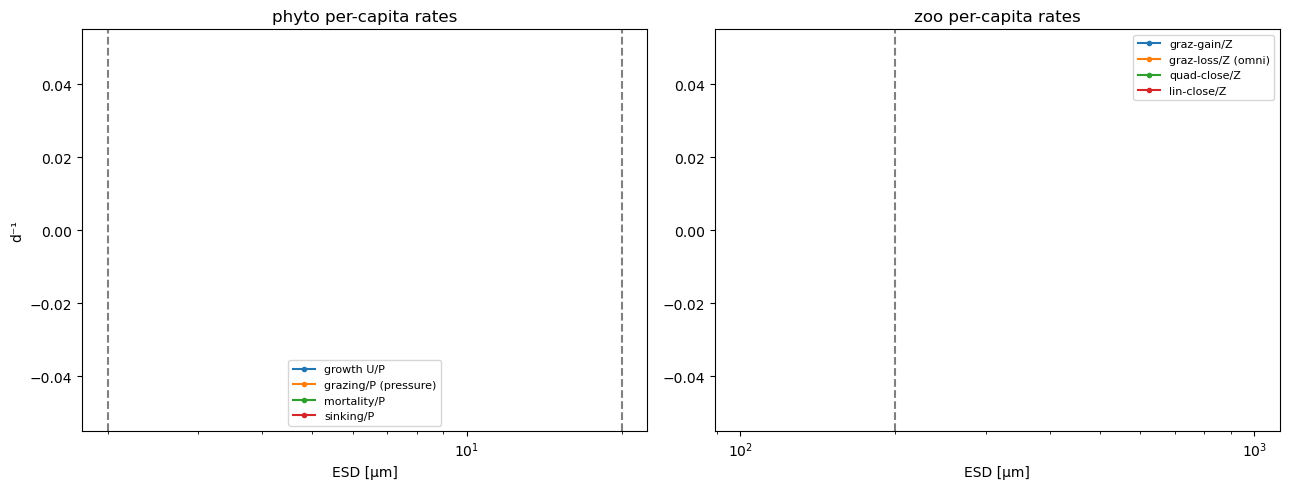

In [5]:
# ── flux-spectrum diagnostic (current omni-Mattern / zlin model) ──
import xso, numpy as np, matplotlib.pyplot as plt
from xso.parscans import StabilityAnalysisHook
N = cbs.N_CLASSES; phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
fz = {**targets['upwelling']['forcing'], 'Grazing__KsZ': np.full(N, 0.15), 'ZooLoss__rate': 0.3}  # targets from Cell 7

USE = 'zlin'      # 'mattern' (quad closure) or 'zlin' (linear+quad)
phiPZ = cbs.phiPZ_omni_mattern
if USE == 'zlin':
    MODEL, STAB, ivars = cbs.model_dist_t3_T_zlin, cbs.model_setup_dist_omni_t3_T_zlin_stability, cbs.make_dist_T_zlin_input_vars(phiPZ)
else:
    MODEL, STAB, ivars = cbs.model_dist_t3_T, cbs.model_setup_dist_omni_t3_T_mattern_stability, cbs.make_dist_T_input_vars(phiPZ)

LONG = 20000.0
ivp_setup = xso.setup(solver='solve_ivp', model=MODEL, time=np.arange(0, LONG, 1.0),
                      input_vars=ivars, output_vars=cbs.SLIM_OUTPUT_VARS, solver_kwargs=cbs.IVP_SOLVER_KWARGS)
ivp = pu.run_single_point(MODEL, ivp_setup, scan_params={}, fixed_overrides=fz)
seed = {'Nutrient__value_init': float(ivp['Nutrient__value'].values[-1000:].mean()),
        'Phytoplankton__biomass_init': np.maximum(ivp['Phytoplankton__biomass'].values[:, -1000:].mean(1), 1e-9),
        'Zooplankton__biomass_init':   np.maximum(ivp['Zooplankton__biomass'].values[:, -1000:].mean(1), 1e-9)}
hook = StabilityAnalysisHook()
with MODEL:
    out = STAB.xsimlab.update_vars(input_vars={**fz, **seed}).xsimlab.run(hooks=[hook])

g = lambda nm, like: out[nm].isel(time=-1).values if nm in out.data_vars else np.zeros_like(like)
P = out['Phytoplankton__biomass'].isel(time=-1).values
Z = out['Zooplankton__biomass'].isel(time=-1).values
U, Gp, Mp, Sp = (g('Growth__uptake_value', P), g('GrazingRouter__loss_P_value', P),
                 g('PhytoLoss__mortality_value', P), g('PhytoSinking__sinking_value', P))
Az, Gz = g('GrazingRouter__gain_Z_value', Z), g('GrazingRouter__loss_Z_value', Z)
Mq, Ml = g('ZooLoss__mortality_value', Z), g('ZooLossLin__mortality_value', Z)
actP = P > 1e-6 * P.max(); actZ = Z > 1e-6 * Z.max()
pc = lambda f, B, act: np.where(act, f / np.where(B > 0, B, np.nan), np.nan)   # per-capita rate

print(f"[{USE}] PHYTO per-capita rates [d-1] at SS  (grazing pressure = graz/P, Mattern Fig 7):")
print(f"{'ESD':>7}{'P':>10}{'growth':>8}{'graz/P':>8}{'mort/P':>8}{'sink/P':>8}{'dom.loss':>9}")
for i in np.where(actP)[0]:
    loss = {'graz': Gp[i], 'mort': Mp[i], 'sink': Sp[i]}; dom = max(loss, key=loss.get)
    print(f"{phyto_esd[i]:7.2f}{P[i]:10.3e}{U[i]/P[i]:8.3f}{Gp[i]/P[i]:8.3f}{Mp[i]/P[i]:8.3f}{Sp[i]/P[i]:8.3f}{dom:>9}")
print(f"\nΣloss split: graz {Gp.sum()/(Gp+Mp+Sp).sum():.2f} / mort {Mp.sum()/(Gp+Mp+Sp).sum():.2f} / sink {Sp.sum()/(Gp+Mp+Sp).sum():.2f}")
print(f"[{USE}] ZOO per-capita: graz-gain, graz-loss(omni), quad-close, lin-close [d-1]:")
for j in np.where(actZ)[0]:
    print(f"{zoo_esd[j]:7.1f}{Z[j]:10.3e}  gain {Az[j]/Z[j]:6.3f}  gloss {Gz[j]/Z[j]:6.3f}  quad {Mq[j]/Z[j]:6.3f}  lin {Ml[j]/Z[j]:6.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(phyto_esd, pc(U,P,actP), 'o-', ms=3, label='growth U/P')
ax[0].plot(phyto_esd, pc(Gp,P,actP), 'o-', ms=3, label='grazing/P (pressure)')
ax[0].plot(phyto_esd, pc(Mp,P,actP), 'o-', ms=3, label='mortality/P')
ax[0].plot(phyto_esd, pc(Sp,P,actP), 'o-', ms=3, label='sinking/P')
ax[0].axvline(2, ls='--', c='grey'); ax[0].axvline(20, ls='--', c='grey')
ax[0].set_xscale('log'); ax[0].set_title('phyto per-capita rates'); ax[0].set_xlabel('ESD [µm]'); ax[0].set_ylabel('d⁻¹'); ax[0].legend(fontsize=8)
ax[1].plot(zoo_esd, pc(Az,Z,actZ), 'o-', ms=3, label='graz-gain/Z')
ax[1].plot(zoo_esd, pc(Gz,Z,actZ), 'o-', ms=3, label='graz-loss/Z (omni)')
ax[1].plot(zoo_esd, pc(Mq,Z,actZ), 'o-', ms=3, label='quad-close/Z')
ax[1].plot(zoo_esd, pc(Ml,Z,actZ), 'o-', ms=3, label='lin-close/Z')
ax[1].axvline(200, ls='--', c='grey'); ax[1].set_xscale('log')
ax[1].set_title('zoo per-capita rates'); ax[1].set_xlabel('ESD [µm]'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [3]:
# ── zoo-linear-closure: solve_ivp scan over m_lin (self-contained, loosened floor) ──
import numpy as np
from xso.parscans import run_xso_parscan
N = cbs.N_CLASSES
bin_defs = co.TARGET_BIN_DEFINITIONS
W = pu.phyto_bin_matrix(cbs.phyto_esd, bin_defs); geomeans = pu.CARIACO_PHYTO_BIN_GEOMEANS
TAIL = 1000

*_, mdf_up, forcing_up = co.load_cariaco_targets('upwelling', months='hplc',
                                                 agg='median', include_temperature=True)
fixed = {**forcing_up, 'Grazing__KsZ': np.full(N, 0.15), 'ZooLoss__rate': 0.3}  # quad m_Z stays 0.3
pcols = [b['column'] for b in bin_defs if b['type'] == 'phyto']
obs_f = np.nanmedian(mdf_up[pcols].dropna().values / mdf_up[pcols].dropna().values.sum(1, keepdims=True), 0)

MLINS = [0.0, 0.01, 0.02, 0.03, 0.05, 0.08, 0.12]    # 0.0 must reproduce the mattern baseline
res = run_xso_parscan(model_file_name='cariaco_baseline_setups',
                      model_name='model_dist_t3_T_zlin',
                      model_setup_name='model_setup_dist_omni_t3_T_zlin_slim_loose',
                      param_name='ZooLossLin__rate',
                      param_values=[np.full(N, v) for v in MLINS], processes=8,
                      fixed_overrides=fixed)

print(f"obs upwelling Pico/Nano/Micro = {np.round(obs_f,3)}\n")
print(f"{'m_lin':>6}{'Pico':>7}{'Nano':>7}{'Micro':>7}{'mcs':>7}{'ΣZ/ΣP':>7}{'minP':>10}{'CV':>9}")
for k, v in enumerate(MLINS):
    P = res['Phytoplankton__biomass'].isel({'ZooLossLin__rate': k}).values[:, -TAIL:]
    Z = res['Zooplankton__biomass'].isel({'ZooLossLin__rate': k}).values[:, -TAIL:]
    if np.isnan(P).any():
        print(f"{v:6.2f}   NaN — genuine divergence (survived loosened floor)"); continue
    Pspec = P.mean(1); b = W @ Pspec; f = b / b.sum(); mcs = 10**(np.log10(geomeans) @ f)
    cv = P.sum(0).std() / abs(P.sum(0).mean())
    print(f"{v:6.2f}{f[0]:7.3f}{f[1]:7.3f}{f[2]:7.3f}{mcs:7.2f}"
          f"{Z.mean(1).sum()/Pspec.sum():7.3f}{P.min():10.2e}{cv:9.4f}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T_zlin' and setup 'model_setup_dist_omni_t3_T_zlin_slim_loose' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 7 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2747 on Growth_uptake[15] = -0.0115 (plus 1 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 22.23526 seconds.
obs upwelling Pico/Nano/Micro = [0.448 0.224 0.313]

 m_lin   Pico   Nano  Micro    mcs  ΣZ/ΣP      minP       CV
  0.00  0.763  0.053  0.185   1.66  1.185 -0.00e+00   0.0042
  0.01  0.745  0.042  0.212   1.85  1.155 -0.00e+00   0.0061
  0.02  0.759  0.035  0.206   1.76  1.142  0.00e+00   0.0037
  0.03  0.747  0.040  0.213   1.84  1.119  0.00e+00   0.0024
  0.05   NaN — genuine divergence (survived loosened floor)
  0.08  0.739  0.084  0.177   1.72  1.045 -0.00e+00   0.0043
  0.12  0.716  0.095  0.189   1.87  0.972  0.00e+00   0.0031


--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_mattern_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 24 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=64.79 on P[0] = -0.0283. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=70.89 on P[0] = -0.0531. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=214.5 on P[3] = -0.00119. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'i

1D Scan complete. Time taken: 89.78937 seconds.
   F_N   Pico   Nano  Micro    mcs    ZoP       CV
  0.50  1.000  0.000  0.000   0.63  1.502   0.0009
  1.17  1.000  0.000  0.000   0.63  1.621   0.0008
  1.85  1.000  0.000  0.000   0.63  1.537   0.0019
  2.52  0.776  0.033  0.191   1.64  1.205   0.0139
  3.20  0.634  0.076  0.290   2.85  0.985   0.0042
  3.87    nan    nan    nan    nan    nan      nan
  4.54    nan    nan    nan    nan    nan      nan
  5.22    nan    nan    nan    nan    nan      nan
  5.89    nan    nan    nan    nan    nan      nan
  6.57    nan    nan    nan    nan    nan      nan
  7.24    nan    nan    nan    nan    nan      nan
  7.91    nan    nan    nan    nan    nan      nan
  8.59    nan    nan    nan    nan    nan      nan
  9.26  1.000  0.000  0.000   0.63  0.510   0.0189
  9.93    nan    nan    nan    nan    nan      nan
 10.61    nan    nan    nan    nan    nan      nan
 11.28    nan    nan    nan    nan    nan      nan
 11.96    nan    nan    nan    nan

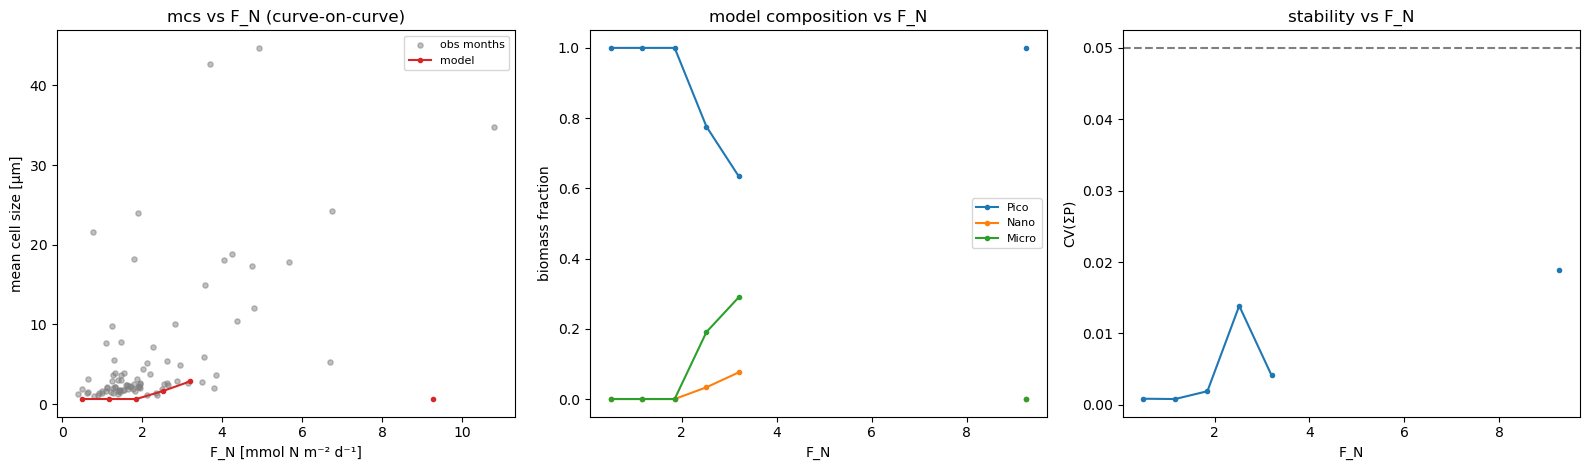

In [4]:
# ── STEP 1: omni-Mattern across F_N — spectrum + obs comparison (curve-on-curve) ──
import numpy as np, matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan
N = cbs.N_CLASSES
bin_defs = co.TARGET_BIN_DEFINITIONS
W = pu.phyto_bin_matrix(cbs.phyto_esd, bin_defs); geomeans = pu.CARIACO_PHYTO_BIN_GEOMEANS
TAIL = 1000

# obs (all months): per-month F_N and composition
*_, mdf_all, _ = co.load_cariaco_targets('all', months='hplc', agg='median', include_temperature=True)
pcols = [b['column'] for b in bin_defs if b['type'] == 'phyto']
obs = mdf_all[pcols + ['FN_mmolN_m2_d']].dropna()
obs_fr = obs[pcols].values / obs[pcols].values.sum(1, keepdims=True)
obs_mcs = 10**(obs_fr @ np.log10(geomeans)); obs_FN = obs['FN_mmolN_m2_d'].values

# model: vary F_N at upwelling depth+temp
*_, _, fc_up = co.load_cariaco_targets('upwelling', months='hplc', agg='median', include_temperature=True)
fixed = {'Inflow__de': fc_up['Inflow__de'], 'Temperature__value': fc_up['Temperature__value'],
         'Grazing__KsZ': np.full(N, 0.15), 'ZooLoss__rate': 0.3}
FN_VALS = np.round(np.linspace(0.5, 16.0, 24), 2)
res = run_xso_parscan(model_file_name='cariaco_baseline_setups', model_name='model_dist_t3_T',
                      model_setup_name='model_setup_dist_omni_t3_T_mattern_slim',
                      param_name='Inflow__FN', param_values=FN_VALS, processes=8, fixed_overrides=fixed)

M = {k: np.full(len(FN_VALS), np.nan) for k in ['Pico','Nano','Micro','mcs','cv','ZoP']}
for k in range(len(FN_VALS)):
    P = res['Phytoplankton__biomass'].isel({'Inflow__FN': k}).values[:, -TAIL:]
    Z = res['Zooplankton__biomass'].isel({'Inflow__FN': k}).values[:, -TAIL:]
    if np.isnan(P).any(): continue
    Pspec=P.mean(1); b=W@Pspec; f=b/b.sum()
    M['Pico'][k],M['Nano'][k],M['Micro'][k]=f; M['mcs'][k]=10**(np.log10(geomeans)@f)
    M['cv'][k]=P.sum(0).std()/abs(P.sum(0).mean()); M['ZoP'][k]=Z.mean(1).sum()/Pspec.sum()

print(f"{'F_N':>6}{'Pico':>7}{'Nano':>7}{'Micro':>7}{'mcs':>7}{'ZoP':>7}{'CV':>9}")
for k,fn in enumerate(FN_VALS):
    print(f"{fn:6.2f}{M['Pico'][k]:7.3f}{M['Nano'][k]:7.3f}{M['Micro'][k]:7.3f}{M['mcs'][k]:7.2f}{M['ZoP'][k]:7.3f}{M['cv'][k]:9.4f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
ax[0].scatter(obs_FN, obs_mcs, s=14, c='grey', alpha=0.5, label='obs months')
ax[0].plot(FN_VALS, M['mcs'], 'o-', ms=3, c='C3', label='model')
ax[0].set_xlabel('F_N [mmol N m⁻² d⁻¹]'); ax[0].set_ylabel('mean cell size [µm]')
ax[0].set_title('mcs vs F_N (curve-on-curve)'); ax[0].legend(fontsize=8)
for nm,c in [('Pico','C0'),('Nano','C1'),('Micro','C2')]:
    ax[1].plot(FN_VALS, M[nm], 'o-', ms=3, c=c, label=nm)
ax[1].set_xlabel('F_N'); ax[1].set_ylabel('biomass fraction'); ax[1].set_title('model composition vs F_N'); ax[1].legend(fontsize=8)
ax[2].plot(FN_VALS, M['cv'], 'o-', ms=3); ax[2].axhline(0.05, ls='--', c='grey')
ax[2].set_xlabel('F_N'); ax[2].set_ylabel('CV(ΣP)'); ax[2].set_title('stability vs F_N')
plt.tight_layout(); plt.show()

In [5]:
# ── regression: does the ORIGINAL herb R0 still behave as documented across F_N? ──
import numpy as np
from xso.parscans import run_xso_parscan
N = cbs.N_CLASSES
bin_defs = co.TARGET_BIN_DEFINITIONS
W = pu.phyto_bin_matrix(cbs.phyto_esd, bin_defs); geomeans = pu.CARIACO_PHYTO_BIN_GEOMEANS
TAIL = 1000
*_, _, fc_up = co.load_cariaco_targets('upwelling', months='hplc', agg='median', include_temperature=True)
fixed = {'Inflow__de': fc_up['Inflow__de'], 'Temperature__value': fc_up['Temperature__value']}  # herb defaults: K_sZ allometric/0.30, m_Z 0.3, σ 0.25
FN_VALS = np.round(np.linspace(0.5, 16.0, 24), 2)
res = run_xso_parscan(model_file_name='cariaco_baseline_setups', model_name='model_dist_t3_T',
                      model_setup_name='model_setup_dist_herb_t3_T_slim',
                      param_name='Inflow__FN', param_values=FN_VALS, processes=8, fixed_overrides=fixed)
print(f"{'F_N':>6}{'Pico':>7}{'Nano':>7}{'Micro':>7}{'mcs':>7}{'CV':>9}{'status':>10}")
for k, fn in enumerate(FN_VALS):
    P = res['Phytoplankton__biomass'].isel({'Inflow__FN': k}).values[:, -TAIL:]
    if np.isnan(P).any():
        print(f"{fn:6.2f}{'':>30}{'NaN':>19}"); continue
    Pspec=P.mean(1); f=(W@Pspec); f=f/f.sum(); cv=P.sum(0).std()/abs(P.sum(0).mean())
    print(f"{fn:6.2f}{f[0]:7.3f}{f[1]:7.3f}{f[2]:7.3f}{10**(np.log10(geomeans)@f):7.2f}{cv:9.4f}{'ok':>10}")

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_herb_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 24 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3318 on P[23] = -0.437 (plus 1 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2830 on P[15] = -0.00205. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 56.12426 seconds.
   F_N   Pico   Nano  Micro    mcs       CV    status
  0.50  1.000  0.000  0.000   0.63   0.0012        ok
  1.17  0.534  0.466  0.000   1.84   0.0007        ok
  1.85  0.384  0.616  0.000   2.60   0.0039        ok
  2.52  0.278  0.438  0.284   6.40   0.0069        ok
  3.20  0.243  0.422  0.336   7.81   0.0049        ok
  3.87  0.199  0.399  0.402  10.05   0.0142        ok
  4.54  0.160  0.258  0.581  16.62   0.0291        ok
  5.22  0.155  0.238  0.606  17.79   0.0611        ok
  5.89  0.129  0.219  0.652  21.02   0.2602        ok
  6.57  0.125  0.198  0.678  22.51   0.3108        ok
  7.24  0.115  0.171  0.714  25.07   0.3779        ok
  7.91  0.105  0.173  0.722  26.11   0.4048        ok
  8.59  0.097  0.144  0.759  28.89   0.3166        ok
  9.26  0.093  0.112  0.795  31.71   0.3328        ok
  9.93  0.080  0.111  0.808  33.68   0.6460        ok
 10.61  0.079  0.099  0.822  34.88   0.4541        ok
 11.28  0.070  0.137  0.793  33.34

In [6]:
# ── EXPLICIT solver comparison: RK45 vs LSODA, omni-Mattern (stable + bloom F_N) ──
import numpy as np, xso
N = cbs.N_CLASSES
bin_defs = co.TARGET_BIN_DEFINITIONS
W = pu.phyto_bin_matrix(cbs.phyto_esd, bin_defs); geomeans = pu.CARIACO_PHYTO_BIN_GEOMEANS
*_, _, fc_up = co.load_cariaco_targets('upwelling', months='hplc', agg='median', include_temperature=True)
base = {'Inflow__de': fc_up['Inflow__de'], 'Temperature__value': fc_up['Temperature__value'],
        'Grazing__KsZ': np.full(N, 0.15), 'ZooLoss__rate': 0.3}
iv = cbs.make_dist_T_input_vars(cbs.phiPZ_omni_mattern)

SOLVERS = {
  'LSODA atol1e-6 rtol1e-4 (current default)': {'method': 'LSODA', 'atol': 1e-6, 'rtol': 1e-4},
  'RK45  atol1e-6 rtol1e-4':                   {'method': 'RK45',  'atol': 1e-6, 'rtol': 1e-4},
  'RK45  atol1e-6 rtol1e-3 (looser)':          {'method': 'RK45',  'atol': 1e-6, 'rtol': 1e-3},
}
for fn in [2.5, 5.0]:
    print(f"\n=== F_N = {fn} ===")
    for name, sk in SOLVERS.items():
        setup = xso.setup(solver='solve_ivp', model=cbs.model_dist_t3_T, time=np.arange(0, 8000, 1.0),
                          input_vars=iv, output_vars=cbs.SLIM_OUTPUT_VARS, solver_kwargs=sk)
        out = pu.run_single_point(cbs.model_dist_t3_T, setup, scan_params={},
                                  fixed_overrides={**base, 'Inflow__FN': fn})
        P = out['Phytoplankton__biomass'].values
        if np.isnan(P).any():
            died = np.where(np.isnan(P[0]))[0]
            print(f"  {name:42s} -> NaN at output step {int(died[0]) if len(died) else '?'}")
        else:
            tail = P[:, -1000:]; f = (W @ tail.mean(1)); f = f / f.sum()
            cv = tail.sum(0).std() / abs(tail.sum(0).mean())
            print(f"  {name:42s} -> ok  P/N/M={np.round(f,3)} mcs={10**(np.log10(geomeans)@f):5.2f} CV={cv:.4f}")


=== F_N = 2.5 ===


/Users/aoop/mambaforge/envs/MS3_3/lib/python3.14/site-packages/scipy/integrate/_ivp/base.py:24: UserWarning: solve_ivp has used 30000 RHS evaluations after 2.3% of the time span — at this rate the run will use ~1.3e+06 total RHS calls. The integration may take a long time. Consider Ctrl-C and restarting with solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems). If you are already on stiff_ivp and nfev is still projecting high, the model is not classically stiff — try solver='solve_ivp' (RK45 default) instead. (This warning fires once per process.)
  return np.asarray(fun(t, y), dtype=dtype)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 69693 RHS evaluations for 469 output points (149/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; wor

  LSODA atol1e-6 rtol1e-4 (current default)  -> NaN at output step 469
  RK45  atol1e-6 rtol1e-4                    -> ok  P/N/M=[0.786 0.032 0.182] mcs= 1.57 CV=0.0051


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=576.2 on P[0] = -0.169. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  RK45  atol1e-6 rtol1e-3 (looser)           -> NaN at output step 577

=== F_N = 5.0 ===


...

  LSODA atol1e-6 rtol1e-4 (current default)  -> NaN at output step 267


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=414.8 on N = -2.45. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  RK45  atol1e-6 rtol1e-4                    -> NaN at output step 415


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=21.03 on P[0] = -0.0375. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  RK45  atol1e-6 rtol1e-3 (looser)           -> NaN at output step 22
